# Customer Segmentation Using RFM Analysis

**Business Objective:**

The objective of this project is to identify valuable customer segments using
Recency, Frequency and Monetary (RFM) analysis.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_excel("/content/Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df = df.dropna(subset=['CustomerID'])

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [9]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [10]:
rfm = df.groupby('CustomerID').agg({
'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
'InvoiceNo': 'count',
'TotalPrice': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

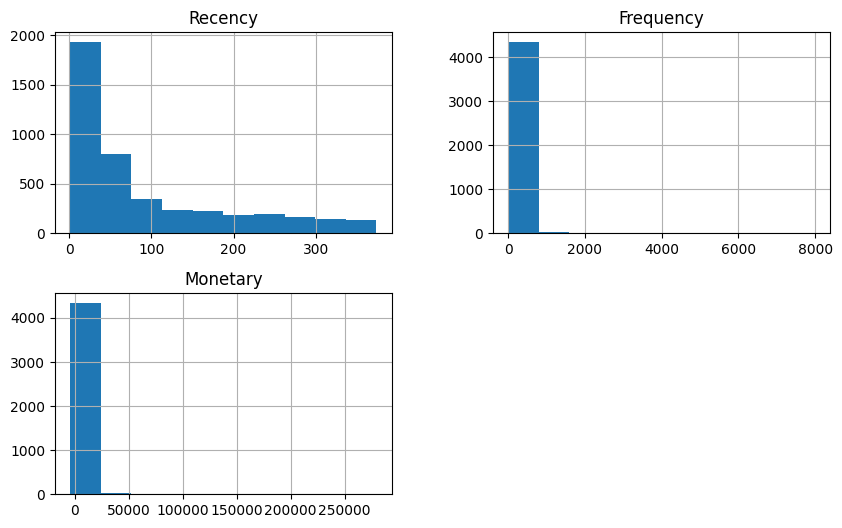

In [11]:
rfm.hist(figsize=(10,6))
plt.show()

**Interpretation:**

Customers with high frequency and high monetary value represent the most
valuable customer segment. Customers with high recency scores may be
at risk of churn.